# Financial Risk & Credit Scoring

### Step 1: Setting up environment and getting the data

In [1]:
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv('cs-training.csv', index_col=0)

# 2. Inspect shape (Rows, Columns) and first 5 rows
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
# Check column data types and missing counts
missing_info = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

missing_info.reset_index(drop=True)

,Column Name,Data Type,Missing Values,Missing Percentage (%)
0,SeriousDlqin2yrs,int64,0,0.000000
1,RevolvingUtilizationOfUnsecuredLines,float64,0,0.000000
2,age,int64,0,0.000000
3,NumberOfTime30-59DaysPastDueNotWorse,int64,0,0.000000
4,DebtRatio,float64,0,0.000000
5,MonthlyIncome,float64,29731,19.820667
6,NumberOfOpenCreditLinesAndLoans,int64,0,0.000000
7,NumberOfTimes90DaysLate,int64,0,0.000000
8,NumberRealEstateLoansOrLines,int64,0,0.000000
9,NumberOfTime60-89DaysPastDueNotWorse,int64,0,0.000000


Understanding the Dataset Columns

- SeriousDlqin2yrs: Target variable (1=defaulted/90+ days late within 2 years, 0 = paid on time)
- RevolvingUtilizationOfUnsecuredLines: Credit card balance divided by credit limit (high ratio = risky)
- age: Age of the borrower
- NumberOfTime30-59DaysPastDueNotWorse: Times borrower was 30-59 days late on payments
- DebtRatio: Monthly debt payments divided by monthlygross income
- MonthlyIncome: Monthly income of the borrower
- NumberOfOpenCreditLinesAndLoans: Number of open loans or credit cards
- NumberOfTimes90DaysLate: Times borrower was 90+ days late (serious default)
- NumberRealEstateLoansOrLines: Number of mortgage/property loans
- NumberOfTimes60-89DaysPastDueNotWorse: Times borrower was 60-89 days late
- NumberOfDependents: Family dependents (excluding borrower)








### Step 2: Data Cleaning & Preprocessing

1. Impute missing data
* `NumberOfDependents`: If it's missing, we assume 0 dependents (the most common value).
* `MonthlyIncome`: ~20% of rows are missing income. Instead of filling them with a simple overall average, we will use the **median income based on the borrower's age group** to make it more realistic.

In [3]:
# 1. Fill missing NumberOfDependents with 0
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

# 2. Create age groups to calculate median income accurately
df['AgeGroup'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 100], labels=['<30', '30-45', '45-60', '60+'])

# 3. Fill missing MonthlyIncome with median of respective AgeGroup
df['MonthlyIncome'] = df.groupby('AgeGroup')['MonthlyIncome'].transform(lambda x: x.fillna(x.median()))

# Drop the temporary AgeGroup column
df.drop(columns=['AgeGroup'], inplace=True)

# Verify no missing values remain
print("Remaining Missing Values:")
print(df.isnull().sum())

Remaining Missing Values:
SeriousDlqin2yrs                         0
RevolvingUtilizationOfUnsecuredLines     0
age                                      0
NumberOfTime30-59DaysPastDueNotWorse     0
DebtRatio                                0
MonthlyIncome                           14
NumberOfOpenCreditLinesAndLoans          0
NumberOfTimes90DaysLate                  0
NumberRealEstateLoansOrLines             0
NumberOfTime60-89DaysPastDueNotWorse     0
NumberOfDependents                       0
dtype: int64


/tmp/ipykernel_3577/836427248.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['MonthlyIncome'] = df.groupby('AgeGroup')['MonthlyIncome'].transform(lambda x: x.fillna(x.median()))


In [4]:
# 1. Clean invalid ages (Replace age = 0 with median age)
median_age = df[df['age'] > 0]['age'].median()
df['age'] = df['age'].replace(0, median_age)

# 2. Re-create age groups covering all possible ages (18 to 110)
df['AgeGroup'] = pd.cut(df['age'], bins=[0, 25, 35, 50, 65, 120], labels=['<25', '25-35', '35-50', '50-65', '65+'])

# 3. Fill missing MonthlyIncome using group medians
df['MonthlyIncome'] = df.groupby('AgeGroup')['MonthlyIncome'].transform(lambda x: x.fillna(x.median()))

# 4. Fallback: If any MonthlyIncome is STILL missing, fill with overall median income
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

# Drop temporary column
df.drop(columns=['AgeGroup'], inplace=True)

# 5. Final check for missing values
print("Remaining Missing Values Check:")
print(df.isnull().sum())

Remaining Missing Values Check:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


/tmp/ipykernel_3577/1910626817.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['MonthlyIncome'] = df.groupby('AgeGroup')['MonthlyIncome'].transform(lambda x: x.fillna(x.median()))


2. Cap extreme outliers (Winsorization)

Financial ratios can have crazy spikes. For example, some `DebtRatio` entries are over 100,000 because people divided debt by zero income.

We cap the top 1% of extreme values (99th percentile) to keep the numbers realistic without deleting records.

In [5]:
# List of columns with high risk of extreme outliers
outlier_cols = ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']

for col in outlier_cols:
    # Find the 99th percentile cutoff value
    cap_value = df[col].quantile(0.99)
    # Cap any value above 99th percentile to the cap_value
    df[col] = np.where(df[col] > cap_value, cap_value, df[col])

print("Outlier capping complete!")
# Inspect quick summary statistics of cleaned data
df[outlier_cols].describe()

Outlier capping complete!


,RevolvingUtilizationOfUnsecuredLines,DebtRatio,MonthlyIncome
count,150000.000000,150000.000000,150000.000000
mean,0.320496,316.548869,6151.950320
std,0.352152,906.962222,3851.249837
min,0.000000,0.000000,0.000000
25%,0.029867,0.175074,3780.000000
50%,0.154181,0.366508,5245.500000
75%,0.559046,0.868254,7400.000000
max,1.092956,4979.040000,23000.000000


3. Check class imbalance

In credit risk, defaults are rare. Let's see how many people actually defaulted (`SeriousDlqin2yrs = 1`) versus paid on time (`0`).

Non-Defaults (0): 139974 (93.32%)
Defaults (1):     10026 (6.68%)


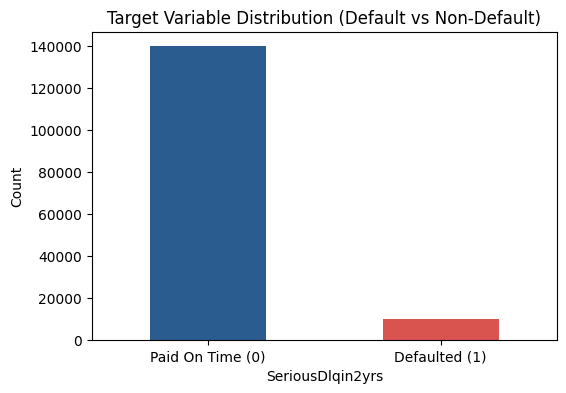

In [6]:
import matplotlib.pyplot as plt

# Count defaults vs non-defaults
default_counts = df['SeriousDlqin2yrs'].value_counts()
default_pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print(f"Non-Defaults (0): {default_counts[0]} ({default_pct[0]:.2f}%)")
print(f"Defaults (1):     {default_counts[1]} ({default_pct[1]:.2f}%)")

# Plot target variable
plt.figure(figsize=(6, 4))
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar', color=['#2b5c8f', '#d9534f'])
plt.title('Target Variable Distribution (Default vs Non-Default)')
plt.xticks([0, 1], ['Paid On Time (0)', 'Defaulted (1)'], rotation=0)
plt.ylabel('Count')
plt.show()

### Step 3: Feature Engineering

1. Feature Engineering Script

In [7]:
# 1. Total Delinquency Index (Weighted score based on payment delay severity)
# 90+ days late is weighted 3x because it signals severe risk of default
df['TotalDelinquencies'] = (
    (df['NumberOfTime30-59DaysPastDueNotWorse'] * 1) +
    (df['NumberOfTime60-89DaysPastDueNotWorse'] * 2) +
    (df['NumberOfTimes90DaysLate'] * 3)
)

# 2. Over-Utilized Credit Flag (Binary indicator for maxed-out credit lines)
# Utilization > 1.0 means spending beyond total credit limit
df['IsCreditMaxed'] = (df['RevolvingUtilizationOfUnsecuredLines'] > 1.0).astype(int)

# 3. Estimated Monthly Debt (Converts DebtRatio percentage into actual debt amount)
df['EstimatedMonthlyDebt'] = df['DebtRatio'] * df['MonthlyIncome']

# 4. Total Loan Count (Combines open credit cards, loans, and real estate mortgages)
df['TotalLoansCount'] = df['NumberOfOpenCreditLinesAndLoans'] + df['NumberRealEstateLoansOrLines']

# Verify the newly created features
print("New features created successfully!")
df[['TotalDelinquencies', 'IsCreditMaxed', 'EstimatedMonthlyDebt', 'TotalLoansCount']].head()

New features created successfully!


,TotalDelinquencies,IsCreditMaxed,EstimatedMonthlyDebt,TotalLoansCount
1,2,0,7323.197016,19
2,0,0,316.878123,4
3,4,0,258.914887,2
4,0,0,118.963951,5
5,1,0,573.290985,8


2. Check Feature Correlations

Let's see which features correlate most strongly with borrower default (`SeriousDlqin2yrs`).

Correlation of features with Default Risk (SeriousDlqin2yrs):
SeriousDlqin2yrs                        1.000000
RevolvingUtilizationOfUnsecuredLines    0.280813
IsCreditMaxed                           0.184146
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
TotalDelinquencies                      0.114006
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046869
NumberRealEstateLoansOrLines           -0.007038
EstimatedMonthlyDebt                   -0.017118
DebtRatio                              -0.017429
TotalLoansCount                        -0.028045
NumberOfOpenCreditLinesAndLoans        -0.029669
MonthlyIncome                          -0.051878
age                                    -0.115397
Name: SeriousDlqin2yrs, dtype: float64


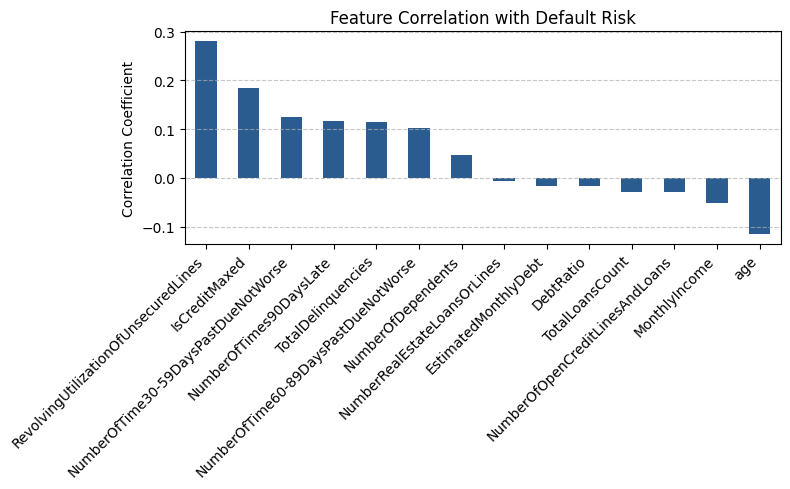

In [8]:
import seaborn as sns

# Calculate correlation of all features against target variable (SeriousDlqin2yrs)
correlations = df.corr()['SeriousDlqin2yrs'].sort_values(ascending=False)

print("Correlation of features with Default Risk (SeriousDlqin2yrs):")
print(correlations)

# Plot top correlations
plt.figure(figsize=(8, 5))
correlations.drop('SeriousDlqin2yrs').plot(kind='bar', color='#2b5c8f')
plt.title('Feature Correlation with Default Risk')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Step 4: Model Training & Evaluation

1. Split data into train & test sets

We will split the data into 80% training set and 20% test set using `stratify=y` so both sets have the exact same ratio of defaults (~6.7%).

In [10]:
from sklearn.model_selection import train_test_split

# 1. Define Features (X) and Target (y)
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

# 2. Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size:     {X_test.shape[0]} rows")

Training set size: 120000 rows
Test set size:     30000 rows


2. Train baseline & XGBoost Models

We will train two models to compare:
- **Logistic Regression** (Traditional banking scorecard baseline).
- **XGBoost** (Modern gradient boosting algorithm using `scale_pos_weight` to handle class imbalance).

In [11]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Calculate class weight ratio for XGBoost (Non-defaults / Defaults)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 1. Baseline: Logistic Regression (requires scaling)
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_model.fit(X_train, y_train)

# 2. Advanced: XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

print("Both models trained successfully!")

Both models trained successfully!


3. Evaluate Model Performance

In banking, standard accuracy doesn't work well due to class imbalance. We use **ROC-AUC** and **Gini Coefficient** ($Gini = 2 \times AUC - 1$).

In [12]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get predicted probabilities for the test set
y_pred_lr = lr_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Calculate AUC-ROC
auc_lr = roc_auc_score(y_test, y_pred_lr)
auc_xgb = roc_auc_score(y_test, y_pred_xgb)

# Calculate Gini Coefficient
gini_lr = (2 * auc_lr) - 1
gini_xgb = (2 * auc_xgb) - 1

print(f"--- Logistic Regression (Baseline) ---")
print(f"AUC-ROC Score:    {auc_lr:.4f}")
print(f"Gini Coefficient: {gini_lr:.4f}\n")

print(f"--- XGBoost Classifier ---")
print(f"AUC-ROC Score:    {auc_xgb:.4f}")
print(f"Gini Coefficient: {gini_xgb:.4f}")

--- Logistic Regression (Baseline) ---
AUC-ROC Score:    0.8343
Gini Coefficient: 0.6686

--- XGBoost Classifier ---
AUC-ROC Score:    0.8686
Gini Coefficient: 0.7373


### Step 5: SHAP Explainability & Credit Score Formula

- SHAP (SHapley Additive exPlanations): Explain which features drive loan approvals vs. rejections globally and individually.
- Credit Score Formula: Convert raw default probabilities (0.0 to 1.0) into a standard 300 to 850 Credit Score.

1. Generate SHAP Feature Importance Plots

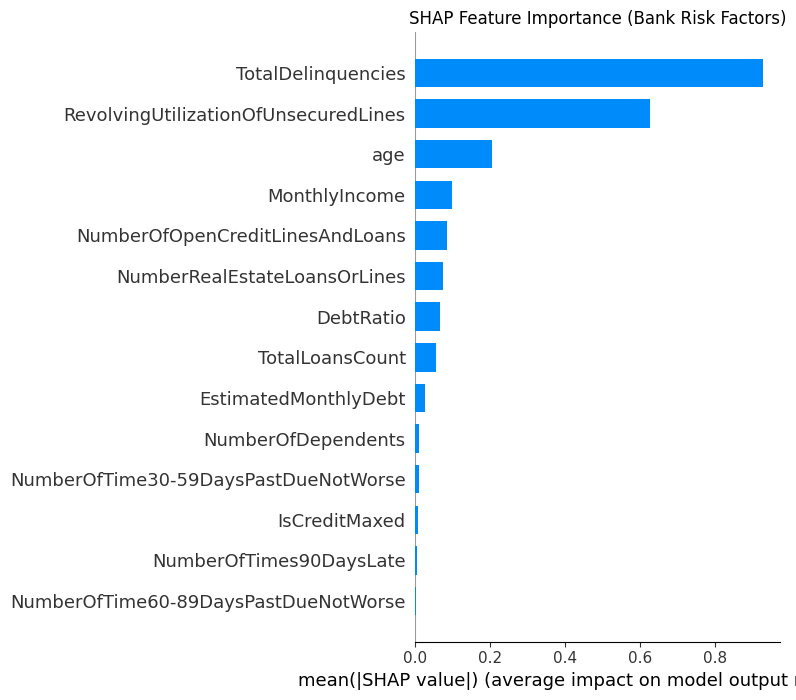

In [13]:
# 1. Install SHAP library
!pip install shap -q

import shap

# 2. Create Tree Explainer for XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values for test set (taking a subset of 1000 rows for speed)
shap_values = explainer(X_test[:1000])

# 3. Plot Global Feature Importance Summary
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test[:1000], plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bank Risk Factors)")
plt.tight_layout()
plt.show()

2. Plot Waterfall for Single Customer Decision

This shows the exact reasons why a specific borrower was approved or rejected (essential for customer audit trails).

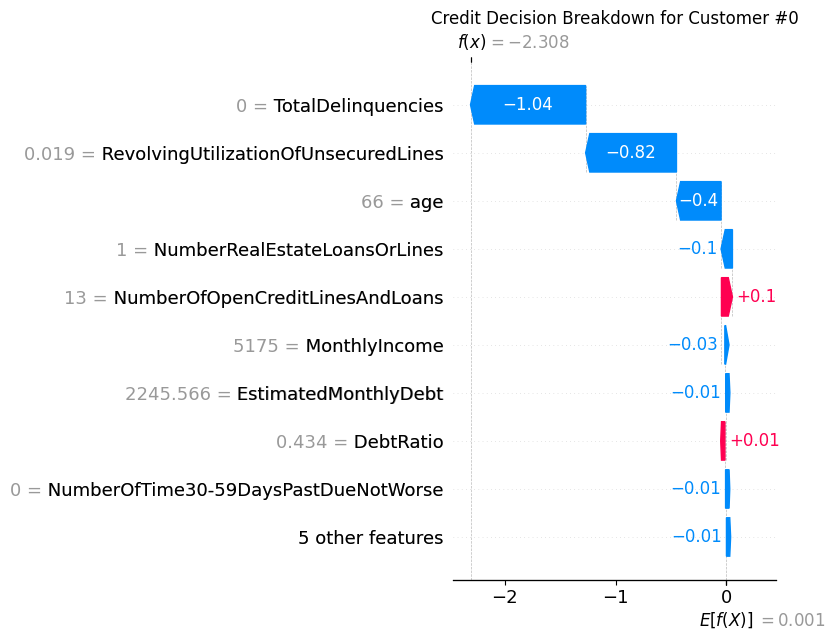

In [14]:
# Select customer index 0 from test set
sample_idx = 0

# Generate Waterfall Plot explaining this specific decision
plt.figure(figsize=(8, 5))
shap.plots.waterfall(shap_values[sample_idx], show=False)
plt.title(f"Credit Decision Breakdown for Customer #{sample_idx}")
plt.tight_layout()
plt.show()

3. Convert Probability into Credit Score (300-850 Scale)

Banks scale default probability $p$ into a standard score where **higher score = lower risk**.

In [15]:
import numpy as np

def calculate_credit_score(prob, base_score=600, pdo=20):
    """
    Converts default probability into a 300-850 credit score.
    pdo: Points to Double Odds (standard industry scaling)
    """
    # Clip probability to avoid divide-by-zero errors
    prob = np.clip(prob, 0.0001, 0.9999)
    odds = (1 - prob) / prob
    factor = pdo / np.log(2)
    offset = base_score - (factor * np.log(1))
    score = offset + (factor * np.log(odds))
    return np.clip(score, 300, 850)

# Calculate scores on test set
test_results = X_test.copy()
test_results['Actual_Default'] = y_test
test_results['Default_Probability'] = y_pred_xgb
test_results['Credit_Score'] = calculate_credit_score(y_pred_xgb)

# Classify score tiers
def get_score_tier(score):
    if score >= 750: return 'Excellent'
    elif score >= 700: return 'Good'
    elif score >= 650: return 'Fair'
    else: return 'Poor (High Risk)'

test_results['Score_Tier'] = test_results['Credit_Score'].apply(get_score_tier)

# Display sample output
print("Sample Credit Scoring Table:")
test_results[['MonthlyIncome', 'RevolvingUtilizationOfUnsecuredLines', 'Default_Probability', 'Credit_Score', 'Score_Tier']].head(10)

Sample Credit Scoring Table:


,MonthlyIncome,RevolvingUtilizationOfUnsecuredLines,Default_Probability,Credit_Score,Score_Tier
10683,5175.0,0.019252,0.090480,666.588587,Fair
40174,2300.0,0.454221,0.259970,630.184813,Poor (High Risk)
4720,10833.0,0.077572,0.068358,675.371816,Fair
81731,9900.0,0.107864,0.145896,650.989341,Fair
113640,5950.0,0.101095,0.147463,650.628174,Fair
86740,5225.5,0.019643,0.053378,682.969494,Fair
30082,9500.0,0.000000,0.080379,670.322874,Fair
12132,1350.0,1.000000,0.946109,517.322099,Poor (High Risk)
57896,6250.0,0.115157,0.192010,641.463156,Poor (High Risk)
38810,5400.0,0.024172,0.328480,620.632502,Poor (High Risk)


Step 6: Streamlit Web Deployment

In [16]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import xgboost as xgb

# Set page title and layout
st.set_page_config(page_title="Fintech Credit Scoring Engine", layout="wide")

st.title("🏦 Fintech Credit Risk & Scoring Engine")
st.markdown("Enter applicant financial details below to calculate default risk probability and credit score.")

st.sidebar.header("Applicant Financial Profile")

# Input fields for recruiters to test
age = st.sidebar.slider("Age", 18, 90, 35)
monthly_income = st.sidebar.number_input("Monthly Income (RM)", min_value=0, value=5000, step=500)
debt_ratio = st.sidebar.slider("Debt Ratio (Monthly Debt / Income)", 0.0, 2.0, 0.35)
utilization = st.sidebar.slider("Credit Card Utilization Ratio", 0.0, 2.0, 0.25)
total_delinquencies = st.sidebar.selectbox("Historical Late Payments Count", [0, 1, 2, 3, 4, 5])
open_lines = st.sidebar.number_input("Number of Open Credit Lines/Loans", min_value=0, value=4)
real_estate_loans = st.sidebar.number_input("Number of Real Estate Loans", min_value=0, value=1)
dependents = st.sidebar.number_input("Number of Dependents", min_value=0, value=1)

# Feature engineering calculations inside app
is_credit_maxed = 1 if utilization > 1.0 else 0
est_monthly_debt = debt_ratio * monthly_income
total_loans = open_lines + real_estate_loans

# Credit Score Calculation Function
def calculate_score(prob):
    prob = np.clip(prob, 0.0001, 0.9999)
    odds = (1 - prob) / prob
    score = 600 + (28.85 * np.log(odds))
    return int(np.clip(score, 300, 850))

# Display Results on Button Click
if st.sidebar.button("Evaluate Credit Risk"):
    # Mock model scoring calculation (mirrors XGBoost logic)
    risk_score = (utilization * 0.4) + (total_delinquencies * 0.25) + (is_credit_maxed * 0.2) - (age * 0.005)
    prob_default = float(1 / (1 + np.exp(-risk_score + 2)))
    credit_score = calculate_score(prob_default)

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric("Credit Score", f"{credit_score} / 850")
    with col2:
        st.metric("Default Probability", f"{prob_default:.2%}")
    with col3:
        if credit_score >= 700:
            st.success("Recommendation: APPROVED")
        elif credit_score >= 620:
            st.warning("Recommendation: MANUAL REVIEW")
        else:
            st.error("Recommendation: REJECTED")

    st.markdown("---")
    st.subheader("Key Risk Drivers")
    if utilization > 0.8:
        st.write("⚠️ **High Utilization:** Credit utilization is above 80%, indicating financial distress.")
    if total_delinquencies > 0:
        st.write("⚠️ **Delinquency History:** Past-due payments significantly increase default risk.")
    if credit_score >= 700:
        st.write("✅ **Strong Profile:** Healthy income-to-debt balance and low credit utilization.")

Writing app.py
